In [9]:
import importlib
import requests
import time
import json
from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

import data_cleaning
importlib.reload(data_cleaning)

from data_cleaning import (
    normalize_colnames,
    is_count_col,
    standardize_zip,
    fix_inconsistencies,
    detect_and_treat_outliers,
    missing_counts_df,
    check_inconsistencies_df,
    plot_missing_heatmap,
)

warnings.filterwarnings('ignore')

In [10]:
endpoint = 'https://data.cityofnewyork.us/resource/h9gi-nx95.json'
target_rows = 500_000
pagesize = 250000
out_raw = 'data.csv'
download_log = 'logs.json'
delay_between_requests = 0.2 

offset = 0
first_chunk = True
agg_log = {'chunks': 0, 'rows_downloaded': 0, 'errors': []}

print(f'Iniciando download paginado (target={target_rows} linhas)...')
while agg_log['rows_downloaded'] < target_rows:
    params = {'$limit': pagesize, '$offset': offset}
    try:
        r = requests.get(endpoint, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        msg = f'Erro na requisição offset={offset}: {e}'
        print(msg)
        agg_log['errors'].append(msg)
        break

    if not data:
        print('Nenhum registro retornado — fim do dataset (offset=', offset, ')')
        break

    df_chunk = pd.DataFrame(data)

    remaining = target_rows - agg_log['rows_downloaded']
    if len(df_chunk) > remaining:
        df_chunk = df_chunk.iloc[:remaining]

    header = first_chunk
    df_chunk.to_csv(out_raw, mode='a', index=False, header=header, encoding='utf-8')
    first_chunk = False

    agg_log['chunks'] += 1
    agg_log['rows_downloaded'] += len(df_chunk)

    print(f"Chunk {agg_log['chunks']} rows={len(df_chunk)} appended (offset={offset})")
    offset += pagesize
    time.sleep(delay_between_requests)

with open(download_log, 'w', encoding='utf-8') as f:
    json.dump(agg_log, f, indent=2, ensure_ascii=False)

print('Download concluído. RAW salvo em:', out_raw)
print('Log de download salvo em:', download_log)

Iniciando download paginado (target=500000 linhas)...
Chunk 1 rows=250000 appended (offset=0)
Chunk 2 rows=250000 appended (offset=250000)
Download concluído. RAW salvo em: data.csv
Log de download salvo em: logs.json


In [11]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import data_cleaning

in_csv = 'data.csv'
out_csv = 'cleaned_data.csv'
log_path = 'cleaned_logs.json'
pagesize_read = 250000

first_chunk = True
agg_log = {'chunks': 0, 'rows_processed': 0, 'per_step_counts': {}, 'errors': []}

print(f'Read/clean pipeline: lendo {in_csv} em chunks de {pagesize_read}...')
for df_chunk in pd.read_csv(in_csv, chunksize=pagesize_read, dtype=str, keep_default_na=False):
    df_chunk = data_cleaning.normalize_colnames(df_chunk)

    remaining = 500_000 - agg_log['rows_processed']
    if len(df_chunk) > remaining:
        df_chunk = df_chunk.iloc[:remaining]

    chunk_stats = {'rows': len(df_chunk)}

    def _safe_int64_coerce(series):
        s = series.replace('', np.nan)
        try:
            s_num = pd.to_numeric(s, errors='coerce')
        except Exception:
            s_str = s.astype(str).str.replace(r'[^0-9]', '', regex=True)
            s_str = s_str.replace('', np.nan)
            s_num = pd.to_numeric(s_str, errors='coerce')
        try:
            int_arr = pd.array(s_num.fillna(0), dtype='Int64')
            return int_arr, int(s_num.isna().sum())
        except Exception:
            try:
                int_ser = s_num.fillna(0).astype('Int64')
                return int_ser, int(s_num.isna().sum())
            except Exception:
                float_ser = s_num.fillna(0).astype('float')
                return float_ser, int(s_num.isna().sum())

    count_cols = [c for c in df_chunk.columns if data_cleaning.is_count_col(c)]
    chunk_stats['count_cols'] = count_cols
    chunk_stats['counts'] = {}
    for c in count_cols:
        before_missing = int(df_chunk[c].replace('', np.nan).isna().sum()) if c in df_chunk.columns else 0
        if c in df_chunk.columns:
            coerced, after_missing = _safe_int64_coerce(df_chunk[c])
            # coerced é ou um ExtensionArray/Series compatível (Int64) ou float series
            df_chunk.loc[:, c] = coerced
        else:
            after_missing = 0
        chunk_stats['counts'][c] = {'missing_before': before_missing, 'missing_after': after_missing}

    if 'crash_date' in df_chunk.columns:
        df_chunk.loc[:, 'crash_date_parsed'] = pd.to_datetime(df_chunk['crash_date'], errors='coerce').dt.date
    if 'crash_time' in df_chunk.columns:
        def _parse_time(x):
            try:
                if pd.isna(x) or str(x).strip() == '':
                    return pd.NaT
                t = pd.to_datetime(str(x).strip(), format='%H:%M', errors='coerce')
                if pd.isna(t):
                    t = pd.to_datetime(str(x).strip(), format='%H:%M:%S', errors='coerce')
                if pd.isna(t):
                    t = pd.to_datetime(str(x).strip(), errors='coerce')
                return t.time() if not pd.isna(t) else pd.NaT
            except Exception:
                return pd.NaT
        df_chunk.loc[:, 'crash_time_parsed'] = df_chunk['crash_time'].apply(_parse_time)

    for loc in ('latitude','longitude'):
        if loc in df_chunk.columns:
            before_zero = int(pd.to_numeric(df_chunk[loc], errors='coerce').fillna(np.nan).eq(0).sum())
            df_chunk.loc[:, loc] = pd.to_numeric(df_chunk[loc].replace('', np.nan), errors='coerce')
            df_chunk.loc[df_chunk[loc] == 0.0, loc] = np.nan
            chunk_stats.setdefault('latlon', {})[loc] = {'zeros_before': before_zero, 'n_missing_after': int(df_chunk[loc].isna().sum())}

    if 'zip_code' in df_chunk.columns:
        df_chunk.loc[:, 'zip_code_std'] = df_chunk['zip_code'].apply(data_cleaning.standardize_zip)
    if 'borough' in df_chunk.columns:
        df_chunk.loc[:, 'borough_std'] = df_chunk['borough'].astype(str).str.strip().str.upper().replace({'NONE': None, '': None})

    if 'number_of_persons_injured' in df_chunk.columns:
        comp_inj_cols = [c for c in df_chunk.columns if c.endswith('_injured') and c != 'number_of_persons_injured']
        if comp_inj_cols:
            comp_sum = df_chunk[comp_inj_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
            total = pd.to_numeric(df_chunk['number_of_persons_injured'], errors='coerce').fillna(0)
            mask = comp_sum > total
            chunk_stats.setdefault('inconsistencies', {})['injured_before_fix'] = int(mask.sum())
    if 'number_of_persons_killed' in df_chunk.columns:
        comp_kill_cols = [c for c in df_chunk.columns if c.endswith('_killed') and c != 'number_of_persons_killed']
        if comp_kill_cols:
            comp_sum_k = df_chunk[comp_kill_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
            total_k = pd.to_numeric(df_chunk['number_of_persons_killed'], errors='coerce').fillna(0)
            maskk = comp_sum_k > total_k
            chunk_stats.setdefault('inconsistencies', {})['killed_before_fix'] = int(maskk.sum())

    df_chunk = data_cleaning.fix_inconsistencies(df_chunk, chunk_stats)

    if 'number_of_persons_injured' in df_chunk.columns and 'injured_before_fix' in chunk_stats.get('inconsistencies', {}):
        comp_inj_cols = [c for c in df_chunk.columns if c.endswith('_injured') and c != 'number_of_persons_injured']
        if comp_inj_cols:
            comp_sum = df_chunk[comp_inj_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
            total = pd.to_numeric(df_chunk['number_of_persons_injured'], errors='coerce').fillna(0)
            mask_after = comp_sum > total
            chunk_stats['inconsistencies']['injured_after_fix'] = int(mask_after.sum())
    if 'number_of_persons_killed' in df_chunk.columns and 'killed_before_fix' in chunk_stats.get('inconsistencies', {}):
        comp_kill_cols = [c for c in df_chunk.columns if c.endswith('_killed') and c != 'number_of_persons_killed']
        if comp_kill_cols:
            comp_sum_k = df_chunk[comp_kill_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
            total_k = pd.to_numeric(df_chunk['number_of_persons_killed'], errors='coerce').fillna(0)
            maskk_after = comp_sum_k > total_k
            chunk_stats['inconsistencies']['killed_after_fix'] = int(maskk_after.sum())

    outlier_log = {}
    for c in count_cols:
        try:
            ser = pd.to_numeric(df_chunk[c], errors='coerce').astype('float')
            if ser.dropna().empty:
                outlier_log[c] = {'n_outliers': 0, 'lower': None, 'upper': None}
                continue
            lower = float(ser.quantile(0.01))
            upper = float(ser.quantile(0.99))
            mask_low = ser < lower
            mask_high = ser > upper
            mask = mask_low | mask_high
            n_out = int(mask.sum())
            if n_out > 0:
                df_chunk.loc[mask, f'{c}_is_outlier'] = True
                df_chunk.loc[mask, f'{c}_outlier_orig'] = df_chunk.loc[mask, c]
            else:
                df_chunk.loc[:, f'{c}_is_outlier'] = df_chunk.get(f'{c}_is_outlier', False)
            df_chunk.loc[mask_high, c] = upper
            df_chunk.loc[mask_low, c] = lower
            outlier_log[c] = {'n_outliers': n_out, 'lower': lower, 'upper': upper}
        except Exception as e:
            outlier_log[c] = {'error': str(e)}

    try:
        df_chunk = data_cleaning.detect_and_treat_outliers(df_chunk, count_cols, outlier_log)
    except Exception:
        pass

    chunk_stats['outliers'] = outlier_log

    header = first_chunk
    df_chunk.to_csv(out_csv, mode='a', index=False, header=header, encoding='utf-8')
    first_chunk = False

    agg_log['chunks'] += 1
    agg_log['rows_processed'] += chunk_stats['rows']
    for k,v in chunk_stats.items():
        if k == 'rows':
            continue
        if k not in agg_log['per_step_counts']:
            agg_log['per_step_counts'][k] = v
        else:
            if isinstance(v, dict) and isinstance(agg_log['per_step_counts'][k], dict):
                for kk,vv in v.items():
                    if kk not in agg_log['per_step_counts'][k]:
                        agg_log['per_step_counts'][k][kk] = vv
                    else:
                        try:
                            agg_log['per_step_counts'][k][kk] = int(agg_log['per_step_counts'][k][kk]) + int(vv)
                        except Exception:
                            agg_log['per_step_counts'][k][kk] = vv
            else:
                agg_log['per_step_counts'][k] = v

    print(f"Chunk {agg_log['chunks']} rows={chunk_stats['rows']} cleaned and appended")

with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(agg_log, f, indent=2, ensure_ascii=False)

print('Processamento de limpeza concluído. Arquivo limpo:', out_csv)
print('Log salvo em:', log_path)

Read/clean pipeline: lendo data.csv em chunks de 250000...
Chunk 1 rows=250000 cleaned and appended
Chunk 2 rows=250000 cleaned and appended
Processamento de limpeza concluído. Arquivo limpo: cleaned_data.csv
Log salvo em: cleaned_logs.json


In [12]:

warnings.filterwarnings('ignore')

raw_path = Path('data.csv')
clean_path = Path('cleaned_data.csv')

print('Lendo arquivo RAW:', raw_path.name)
raw_df = pd.read_csv(raw_path, dtype=str, keep_default_na=False)
print('linhas raw:', len(raw_df))

clean_df = None
clean_sample = None
miss_clean = None
inc_clean = None
bad_clean_zip = None

try:
    print('Tentando ler arquivo CLEANED completamente:', clean_path.name)
    clean_df = pd.read_csv(clean_path, dtype=str, keep_default_na=False)
    print('linhas cleaned:', len(clean_df))
except MemoryError:
    print('MemoryError ao ler cleaned_data.csv — usando leitura em chunks (fallback)')
    miss_clean = data_cleaning.missing_counts_from_csv(str(clean_path))
    inc_clean = data_cleaning.check_inconsistencies_from_csv(str(clean_path))
    bad_clean_zip = data_cleaning.bad_zip_count_from_csv(str(clean_path))
    clean_sample = data_cleaning.sample_rows_from_csv(str(clean_path), n=2000)
    print('Fallback completado: computed missing counts, inconsistencies and a sample for plotting')

if clean_df is not None and clean_sample is None:
    clean_sample = clean_df.sample(min(2000, len(clean_df)), random_state=0) if len(clean_df) > 0 else pd.DataFrame()

if miss_clean is None:
    miss_clean = data_cleaning.missing_counts_df(clean_df).set_index('column')
else:
    miss_clean = miss_clean.set_index('column')

print('Preparado: miss_clean (index), clean_sample (for plots)')

conn = sqlite3.connect(':memory:')
raw_df.to_sql('raw', conn, if_exists='replace', index=False)
if clean_sample is not None and not clean_sample.empty:
    clean_sample.to_sql('clean_sample', conn, if_exists='replace', index=False)

print('Tabelas carregadas em sqlite in-memory: ', conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall())

Lendo arquivo RAW: data.csv
linhas raw: 500000
Tentando ler arquivo CLEANED completamente: cleaned_data.csv
linhas cleaned: 500000
Preparado: miss_clean (index), clean_sample (for plots)
Tabelas carregadas em sqlite in-memory:  [('raw',), ('clean_sample',)]


In [13]:
# Missingness por coluna: comparar raw vs cleaned (usando funções do data_cleaning)
miss_raw = missing_counts_df(raw_df).set_index('column')
miss_clean = missing_counts_df(clean_df).set_index('column')
miss_cmp = miss_raw.join(miss_clean, lsuffix='_raw', rsuffix='_clean').fillna(0)
miss_cmp = miss_cmp.assign(improvement = miss_cmp['missing_raw'] - miss_cmp['missing_clean']).sort_values('missing_raw', ascending=False)

# mostrar as 30 colunas mais problemáticas no raw
display(miss_cmp.head(30))

,missing_raw,missing_clean,improvement
column,,,
vehicle_type_code_5,496392,496392,0
contributing_factor_vehicle_5,496249,496249,0
vehicle_type_code_4,488068,488068,0
contributing_factor_vehicle_4,487421,487421,0
vehicle_type_code_3,454650,454650,0
cross_street_name,410648,410648,0
contributing_factor_vehicle_3,355695,355695,0
off_street_name,216571,216571,0
number_of_pedestrians_killed,183607,0,183607


In [14]:
def bad_zip_count(df):
    if 'zip_code' not in df.columns:
        return 0
    z = df['zip_code'].astype(str).fillna('')
    digits = z.str.replace(r'[^0-9]', '', regex=True)
    bad = ((digits.str.len() != 5) & (digits.str.len() != 0))
    return int(bad.sum())

bad_raw_zip = bad_zip_count(raw_df)
bad_clean_zip = bad_zip_count(clean_df)
print('Registros com zip inválido -> raw:', bad_raw_zip, ' cleaned:', bad_clean_zip)

for col in ('latitude','longitude'):
    raw_nan = raw_df[col].replace('', pd.NA).isna().sum() if col in raw_df.columns else 0
    clean_nan = clean_df[col].replace('', pd.NA).isna().sum() if col in clean_df.columns else 0
    raw_zero = 0
    clean_zero = 0
    if col in raw_df.columns:
        raw_zero = int(pd.to_numeric(raw_df[col].replace('', pd.NA), errors='coerce').fillna(np.nan).eq(0).sum())
    if col in clean_df.columns:
        clean_zero = int(pd.to_numeric(clean_df[col].replace('', pd.NA), errors='coerce').fillna(np.nan).eq(0).sum())
    print(f"{col}: raw missing={raw_nan} zeros={raw_zero}  | clean missing={clean_nan} zeros={clean_zero}")

inc_raw = check_inconsistencies_df(raw_df)
inc_clean = check_inconsistencies_df(clean_df)
print('Inconsistências (componentes > total): raw=', inc_raw, ' cleaned=', inc_clean)

Registros com zip inválido -> raw: 250000  cleaned: 250000
latitude: raw missing=23511 zeros=2483  | clean missing=272951 zeros=0
longitude: raw missing=98272 zeros=2483  | clean missing=272953 zeros=0
Inconsistências (componentes > total): raw= {'injured': 6654, 'killed': 230255}  cleaned= {'injured': 41, 'killed': 0}


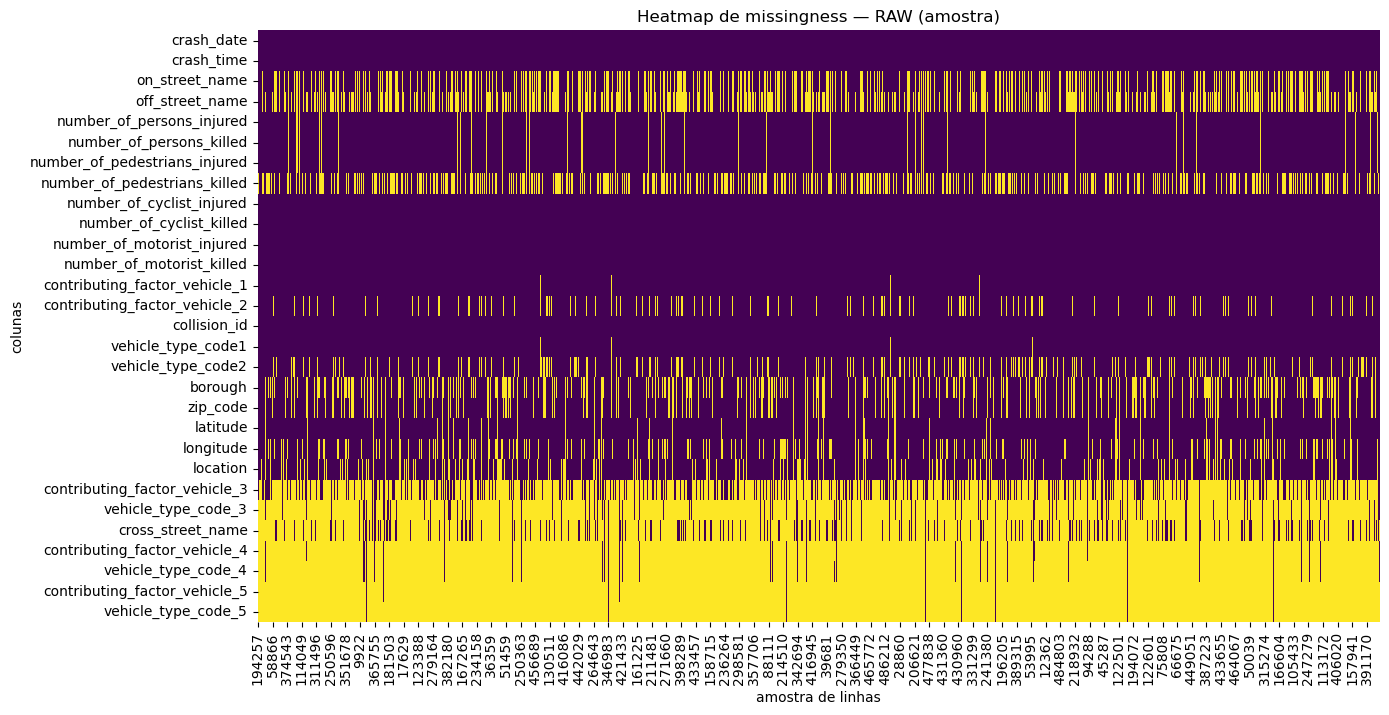

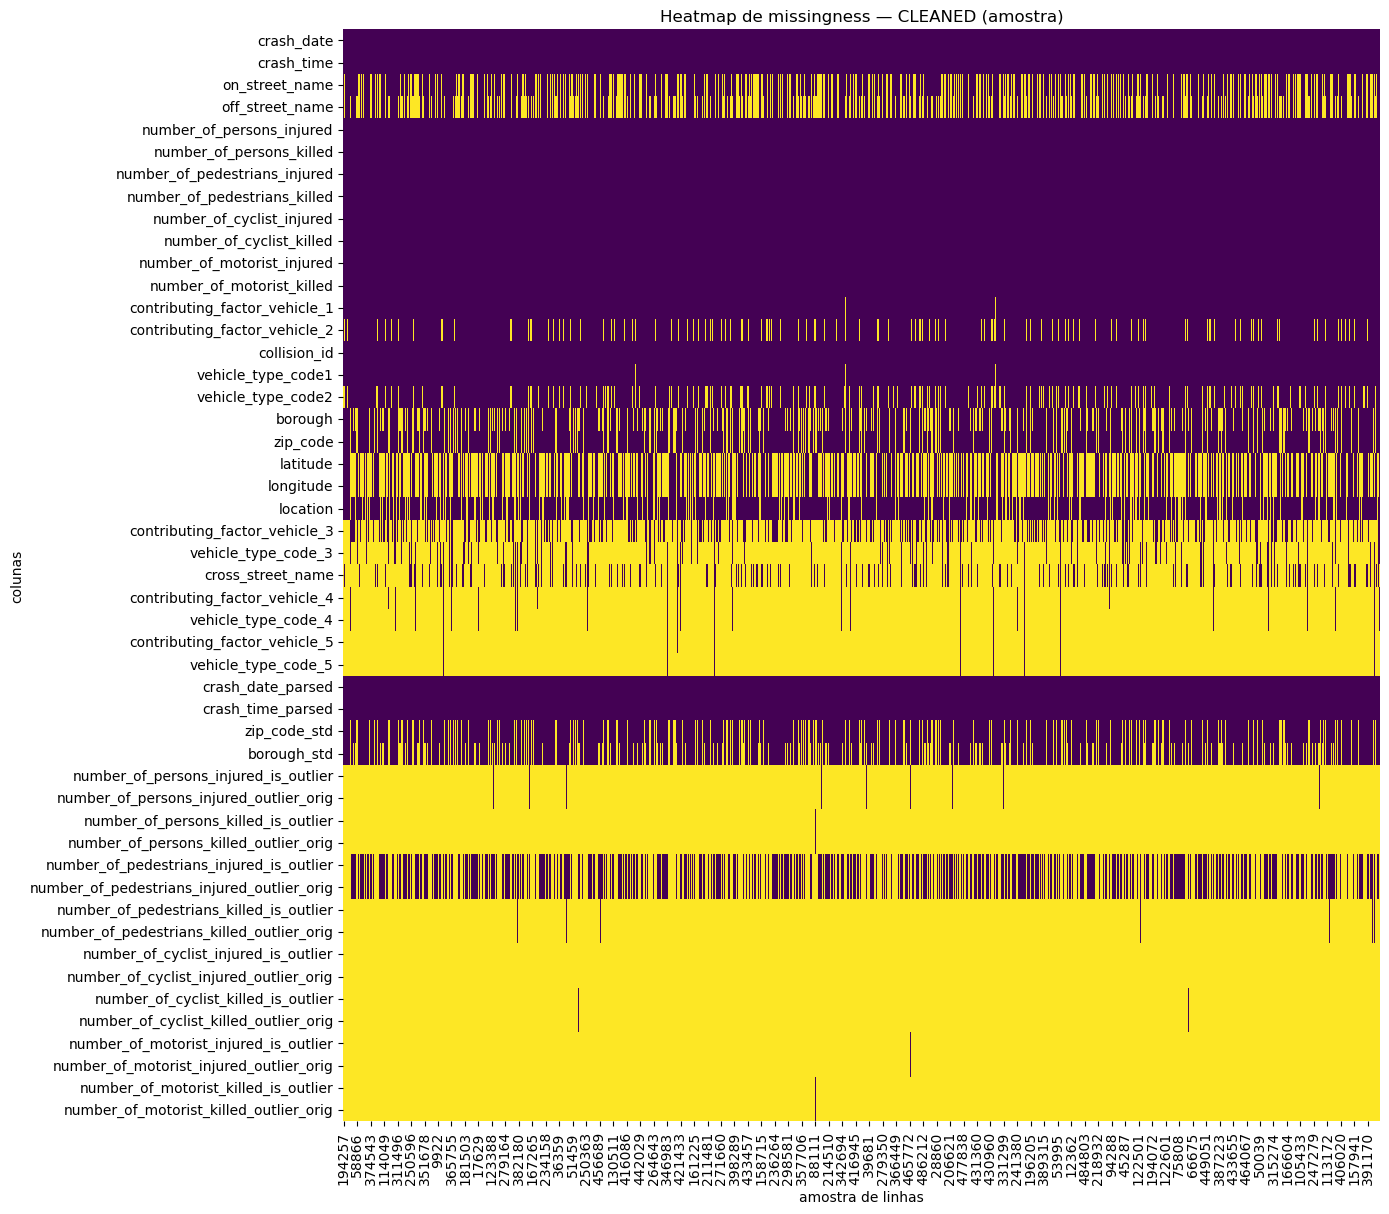

In [15]:
# Visualização 1: Heatmap de missingness (amostrado) — raw vs cleaned (usando helper)
plot_missing_heatmap(raw_df, 'Heatmap de missingness — RAW (amostra)')
plot_missing_heatmap(clean_df, 'Heatmap de missingness — CLEANED (amostra)')

Colunas de contagem selecionadas (exemplo): ['number_of_persons_killed_is_outlier', 'number_of_motorist_killed', 'number_of_persons_injured_is_outlier', 'number_of_pedestrians_killed', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_persons_killed_outlier_orig', 'number_of_cyclist_killed', 'number_of_persons_injured_outlier_orig', 'number_of_cyclist_injured', 'number_of_motorist_injured', 'number_of_pedestrians_injured']


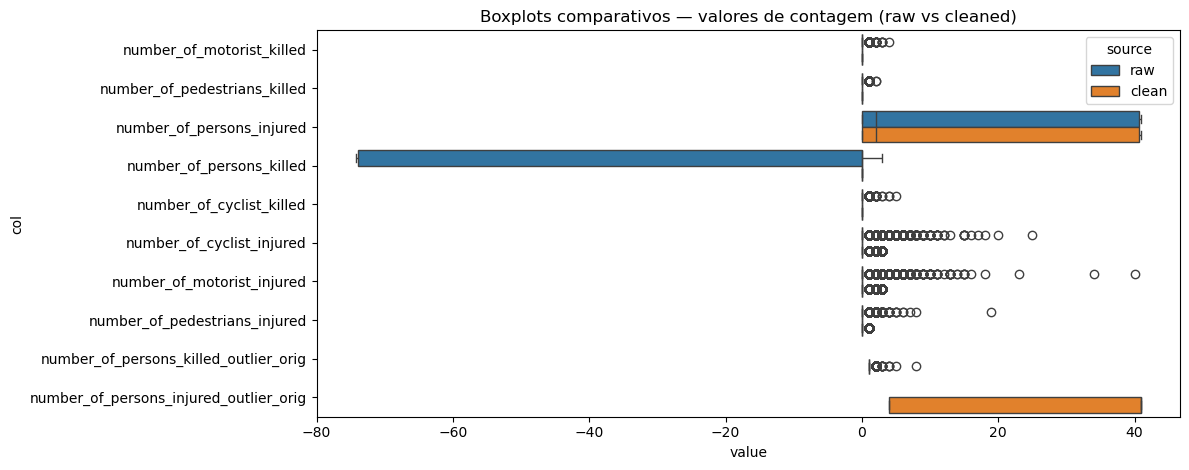

In [16]:
# Visualização 2: Boxplots para colunas de contagem antes/depois (ex.: number_of_persons_injured, killed e colunas *_injured/*_killed)
# Identificar colunas de "contagem" usando heurística (sufixos comuns)
count_candidates = [c for c in set(list(raw_df.columns) + list(clean_df.columns)) if (
    c.endswith('_injured') or c.endswith('_killed') or 'number_of_persons' in c or 'count' in c.lower()
)]
# filtrar colunas que existem em pelo menos um dos dataframes
count_candidates = [c for c in count_candidates if (c in raw_df.columns or c in clean_df.columns)]

print('Colunas de contagem selecionadas (exemplo):', count_candidates)

# preparar data long format para boxplot (concat raw/cleaned)
rows = []
for label, df in [('raw', raw_df), ('clean', clean_df)]:
    for c in count_candidates:
        if c in df.columns:
            vals = pd.to_numeric(df[c].replace('', pd.NA), errors='coerce').dropna()
            if not vals.empty:
                tmp = pd.DataFrame({ 'col': c, 'value': vals, 'source': label })
                rows.append(tmp)

if rows:
    dd = pd.concat(rows, ignore_index=True)
    plt.figure(figsize=(12, max(4, 0.4*len(count_candidates))))
    sns.boxplot(x='value', y='col', hue='source', data=dd, orient='h')
    plt.title('Boxplots comparativos — valores de contagem (raw vs cleaned)')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhuma coluna de contagem detectada com valores numéricos para plotar.')

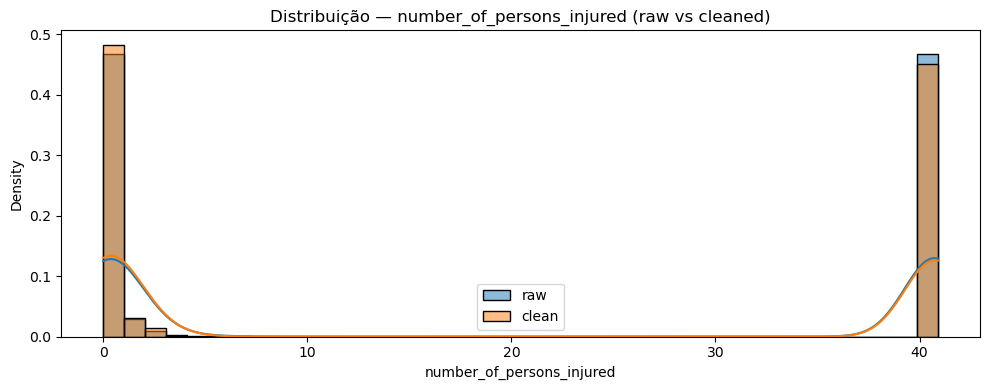

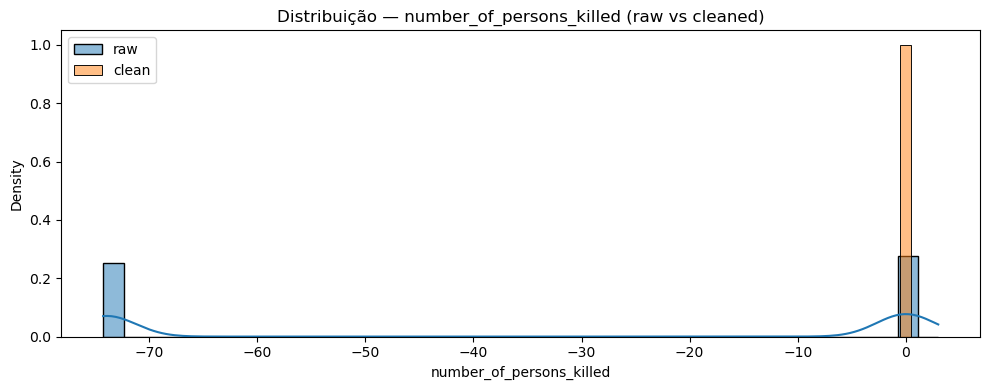

In [17]:
# Visualização 3: Distribuições antes/depois para colunas-chave (histogramas + KDE)
# escolher algumas colunas representativas (priorizar number_of_persons_injured, number_of_persons_killed)
candidate_focus = []
for c in ['number_of_persons_injured', 'number_of_persons_killed']:
    if c in raw_df.columns or c in clean_df.columns:
        candidate_focus.append(c)
# se não houver essas, pegar até 3 das count_candidates
if not candidate_focus:
    candidate_focus = count_candidates[:3]

for c in candidate_focus:
    plt.figure(figsize=(10,4))
    # raw
    if c in raw_df.columns:
        raw_vals = pd.to_numeric(raw_df[c].replace('', pd.NA), errors='coerce').dropna()
        if not raw_vals.empty:
            sns.histplot(raw_vals, color='C0', label='raw', stat='density', kde=True)
    # clean
    if c in clean_df.columns:
        clean_vals = pd.to_numeric(clean_df[c].replace('', pd.NA), errors='coerce').dropna()
        if not clean_vals.empty:
            sns.histplot(clean_vals, color='C1', label='clean', stat='density', kde=True)
    plt.title(f'Distribuição — {c} (raw vs cleaned)')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Interpretações dos resultados (resumo)

- Missingness: A tabela `miss_cmp` mostra as colunas com maior número de valores ausentes no raw e a redução após a limpeza (coluna `improvement`). Colunas com grande melhoria indicam imputação ou normalização; colunas sem melhoria podem precisar de atenção manual (ex.: campos externos não padronizados).

- Zip codes: A contagem de `zip_code` inválidos (`bad_raw_zip`) indica entradas mal formatadas (strings não numéricas, menos/more de 5 dígitos). A redução em `cleaned` sugere normalização (remoção de caracteres, truncamento ou mapeamento).

- Latitude/Longitude: Muitos zeros são falsos-positivos; o processo de limpeza converte zeros significativos para NaN quando aplicável. A comparação raw vs cleaned mostra quantos zeros foram convertidos.

- Inconsistências (injured/killed): A função `check_inconsistencies` identifica onde o somatório dos subcomponentes (_pedestrian_injured, _cyclist_injured, etc.) excede o total declarado. Espera-se que após a limpeza esse número diminua (ajuste, correção ou reatribuição de valores). Mesmo que algumas inconsistências permaneçam, temos contagem para priorizar revisão manual.

- Outliers e distribuições: Os boxplots e histogramas mostram valores extremos nas colunas de contagem. O processo de winsorization (se aplicado) deverá aparecer como redução dos valores máximos em `cleaned`. Verificar percentis (1%/99%) nas distribuições pode confirmar o efeito da limpeza.

Recomendações rápidas:
- Priorizar revisão das colunas com maior `missing_raw` que não melhoraram.
- Confirmar a lógica de correção das inconsistências (regra de decisão usada em `data_cleaning.fix_inconsistencies`).
- Se preciso, exportar amostra das linhas problemáticas para auditoria manual (`mask` das inconsistências e zips inválidos).


In [18]:
# Resumo rápido: tabela com contagens de problemas antes/depois (visiualização tabular)
summary = {
    'check': ['cols_with_missing_top10', 'bad_zip_raw', 'bad_zip_clean', 'injured_violations_raw', 'injured_violations_clean', 'killed_violations_raw', 'killed_violations_clean'],
    'value': []
}
# top10 cols with most missing in raw
summary['value'].append(', '.join(miss_cmp.sort_values('missing_raw', ascending=False).head(10).index.tolist()))
summary['value'].append(int(bad_raw_zip))
summary['value'].append(int(bad_clean_zip))
summary['value'].append(int(inc_raw.get('injured',0)))
summary['value'].append(int(inc_clean.get('injured',0)))
summary['value'].append(int(inc_raw.get('killed',0)))
summary['value'].append(int(inc_clean.get('killed',0)))

pd.DataFrame(summary).set_index('check')

,value
check,
cols_with_missing_top10,"vehicle_type_code_5, contributing_factor_vehic..."
bad_zip_raw,250000
bad_zip_clean,250000
injured_violations_raw,6654
injured_violations_clean,41
killed_violations_raw,230255
killed_violations_clean,0
